<a href="https://colab.research.google.com/github/Divyashree-02112006/divya-codeboosters-2026/blob/main/Day%20-%202/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

pandas version: 2.2.2
sqlite3 version: 2.6.0


In [5]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students,{df.shape[1]} columns")
print(f"columns:{df.columns.tolist()}")
df.head(3)

Dataset loaded: 30 students,13 columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [7]:
conn=sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql("students", conn, if_exists="replace", index=False)

result = pd.read_sql("SELECT * FROM students LIMIT 5", conn)

print(result)






   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [9]:
def run_query(sql,description="students"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

In [10]:
query1="""
  SELECT student_id,name,department,math_score,attendance_percentage
  FROM students
  LIMIT 10
"""
result1=run_query(query1,"Query 1:First 10 Students (SELECT + LIMIT)")

Query 1:First 10 Students (SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [11]:
query1="""
  SELECT student_id,name,department
  FROM students
  LIMIT 5
"""
result1=run_query(query1,"Query 1:First 5 Students (SELECT + LIMIT)")

Query 1:First 5 Students (SELECT + LIMIT)
 student_id         name       department
       1001 Aarav Sharma Computer Science
       1002  Priya Patel Computer Science
       1003  Rohit Verma      Electronics
       1004  Sneha Reddy       Mechanical
       1005   Arjun Nair Computer Science


In [12]:
query1="""
  SELECT student_id,name,department,math_score
  FROM students
  ORDER BY math_score DESC
  LIMIT 5
"""
result1=run_query(query1,"Top 5 Math Scores (ORDER BY DESC +LIMIT)")

Top 5 Math Scores (ORDER BY DESC +LIMIT)
 student_id           name       department  math_score
       1010     Ananya Das Computer Science          95
       1022    Tanvi Mehta Computer Science          93
       1005     Arjun Nair Computer Science          92
       1030 Akanksha Yadav Computer Science          91
       1018 Swati Kulkarni Computer Science          90


In [13]:
query1="""
  SELECT student_id,name,math_score,science_score,programming_score,attendance_percentage
  FROM students
  WHERE department='Computer Science'
  ORDER BY programming_score DESC
"""
result1=run_query(query1,"Query 3:WHERE filter")

Query 3:WHERE filter
 student_id           name  math_score  science_score  programming_score  attendance_percentage
       1010     Ananya Das          95             89                 97                     98
       1022    Tanvi Mehta          93             90                 96                     97
       1005     Arjun Nair          92             88                 95                     90
       1030 Akanksha Yadav          91             93                 94                     95
       1008    Divya Singh          88             91                 93                     96
       1018 Swati Kulkarni          90             87                 92                     94
       1001   Aarav Sharma          85             78                 91                     92
       1025      Amit Bose          86             82                 89                     91
       1013     Suresh Rao          83             86                 88                     88
       1027  Gaurav

In [ ]:
query1="""
  SELECT student_id,name,attendance_percentage
  FROM students
  WHERE  department != 'Mechanical' AND attendance_percentage > 93
  ORDER BY attendance_percentage DESC
  LIMIT 3
"""
result1=run_query(query1,"Query 4:High attendance ")

Query 4:High attendance 
 student_id        name  attendance_percentage
       1010  Ananya Das                     98
       1022 Tanvi Mehta                     97
       1008 Divya Singh                     96


In [ ]:
query1="""
  SELECT student_id,name,department
  FROM students
  WHERE  name between 'A' AND 'F'

"""
result1=run_query(query1,"Query5")

Query5
 student_id           name       department
       1001   Aarav Sharma Computer Science
       1005     Arjun Nair Computer Science
       1008    Divya Singh Computer Science
       1010     Ananya Das Computer Science
       1015    Ajay Tiwari Computer Science
       1019 Deepak Chauhan       Mechanical
       1025      Amit Bose Computer Science
       1030 Akanksha Yadav Computer Science


In [14]:
query5 = """
SELECT gender,
COUNT(*) as num_students,
AVG(math_score) as avg_math,
AVG(programming_score) as avg_programming,
AVG(attendance_percentage) as avg_attendance
FROM students
GROUP BY gender
"""
result5 = run_query(query5)

students
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15 78.466667             70.2       88.533333
  Male            15 73.666667             65.0       80.466667


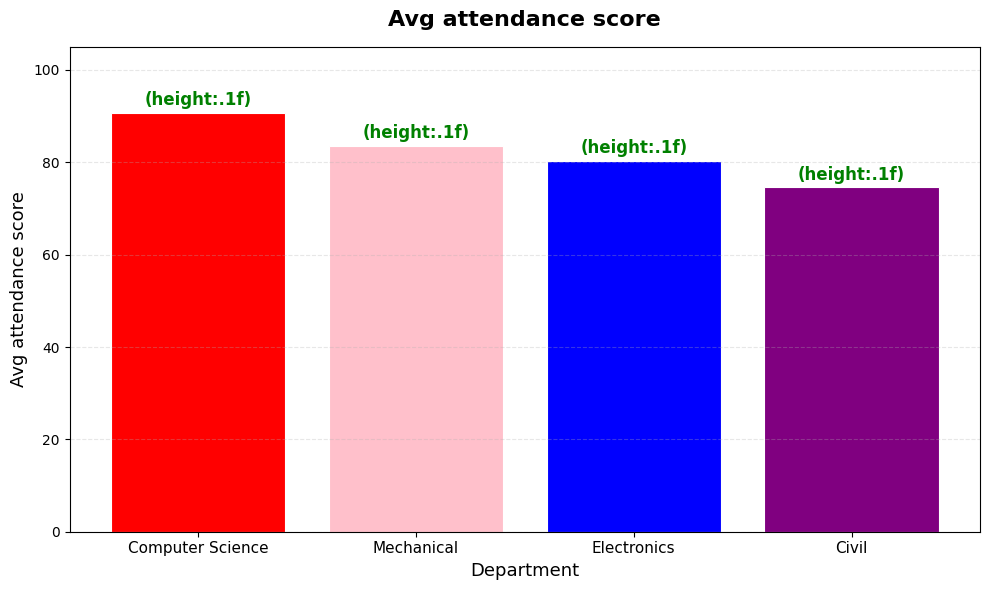

In [24]:
chart1_sql="""SELECT department,ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_attendance DESC
"""

chart1_data=pd.read_sql_query(chart1_sql,conn)

fig,ax=plt.subplots(figsize=(10,6))

bar_colors=['red','pink','blue','purple']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_attendance'],
    color= bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
  h=bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width()/2,
      h+0.8,
      f"(height:.1f)",
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='green'
  )
ax.set_title('Avg attendance score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Department',fontsize=13)
ax.set_ylabel('Avg attendance score',fontsize=13)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()